# **Importando Bibliotecas**

In [8]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

print("Bibliotecas carregadas com sucesso")

Bibliotecas carregadas com sucesso


# **Carregando a Base**

In [9]:
import pandas as pd

caminho_csv = "/content/desafio_nps_fase_1.csv"

df = pd.read_csv(caminho_csv)

print("Arquivo usado:", caminho_csv)
print("Base carregada com", df.shape[0], "linhas e", df.shape[1], "colunas")

display(df.head())

Arquivo usado: /content/desafio_nps_fase_1.csv
Base carregada com 2500 linhas e 19 colunas


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


# **Visão inicial da base**

In [10]:
print("Tamanho da base:")
print(df.shape)

print("\nColunas da base:")
print(df.columns.tolist())

print("\nTipos de dados:")
display(df.dtypes)

print("\nValores nulos por coluna:")
display(df.isna().sum().sort_values(ascending=False))

Tamanho da base:
(2500, 19)

Colunas da base:
['customer_id', 'customer_age', 'customer_region', 'customer_tenure_months', 'order_id', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'nps_score', 'repeat_purchase_30d', 'complaints_count', 'csat_internal_score']

Tipos de dados:


,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64



Valores nulos por coluna:


,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


# **Checar duplicidade**

In [46]:
print("Quantidade de pedidos duplicados:")

if "order_id" in df.columns:
    print(df["order_id"].duplicated().sum())
else:
    print("A coluna order_id não existe na base.")

Quantidade de pedidos duplicados:
0


# Criar variáveis auxiliares

In [47]:
condicoes_nps = [
    df["nps_score"] <= 6,
    (df["nps_score"] > 6) & (df["nps_score"] < 9),
    df["nps_score"] >= 9
]

categorias_nps = ["Detrator", "Neutro", "Promotor"]

df["nps_category"] = np.select(
    condicoes_nps,
    categorias_nps,
    default="Sem classificação"
)

df["is_detractor"] = (df["nps_score"] <= 6).astype(int)

df["contact_range"] = pd.cut(
    df["customer_service_contacts"],
    bins=[-1, 0, 2, 999],
    labels=["Nenhum", "1-2 contatos", "3+ contatos"]
)

df["complaint_range"] = pd.cut(
    df["complaints_count"],
    bins=[-1, 0, 2, 5, 999],
    labels=["Nenhuma", "1-2", "3-5", "6+"]
)

df["resolution_range"] = pd.cut(
    df["resolution_time_days"],
    bins=[-1, 2, 5, 10, 999],
    labels=["Até 2 dias", "3-5 dias", "6-10 dias", "11+ dias"]
)

df["delay_range"] = pd.cut(
    df["delivery_delay_days"],
    bins=[-1, 0, 2, 5, 999],
    labels=["Sem atraso", "1-2 dias", "3-5 dias", "6+ dias"]
)

df["age_range"] = pd.cut(
    df["customer_age"],
    bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"]
)

df["tenure_range"] = pd.cut(
    df["customer_tenure_months"],
    bins=[-1, 12, 36, 72, 999],
    labels=["< 1 ano", "1-3 anos", "3-6 anos", "6+ anos"]
)

print("Variáveis auxiliares criadas")

df[[
    "customer_id",
    "nps_score",
    "nps_category",
    "is_detractor",
    "contact_range",
    "complaint_range",
    "resolution_range",
    "delay_range"
]].head(10)

Variáveis auxiliares criadas


,customer_id,nps_score,nps_category,is_detractor,contact_range,complaint_range,resolution_range,delay_range
0,1,6.90,Neutro,0,Nenhum,3-5,3-5 dias,1-2 dias
1,2,2.40,Detrator,1,Nenhum,3-5,6-10 dias,3-5 dias
2,3,4.80,Detrator,1,3+ contatos,6+,3-5 dias,1-2 dias
3,4,5.90,Detrator,1,1-2 contatos,3-5,11+ dias,1-2 dias
4,5,6.10,Neutro,0,1-2 contatos,3-5,Até 2 dias,1-2 dias
5,6,0.90,Detrator,1,1-2 contatos,3-5,3-5 dias,3-5 dias
6,7,1.40,Detrator,1,3+ contatos,6+,3-5 dias,3-5 dias
7,8,0.00,Detrator,1,Nenhum,1-2,Até 2 dias,3-5 dias
8,9,6.20,Neutro,0,1-2 contatos,3-5,6-10 dias,3-5 dias
9,10,2.70,Detrator,1,Nenhum,1-2,6-10 dias,1-2 dias


## **Resumo executivo da base**

In [48]:
# Resumo executivo da base

total_clientes = len(df)
nps_medio = df["nps_score"].mean()

dist_nps = (
    df["nps_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

nps_geral = dist_nps.get("Promotor", 0) - dist_nps.get("Detrator", 0)

print("Resumo executivo da base")
print("-" * 40)
print("Total de clientes/pedidos:", total_clientes)
print("NPS médio:", round(nps_medio, 2))
print("NPS geral estimado:", round(nps_geral, 2))
print("\nDistribuição por categoria:")
display(dist_nps)

Resumo executivo da base
----------------------------------------
Total de clientes/pedidos: 2500
NPS médio: 4.38
NPS geral estimado: -69.64

Distribuição por categoria:


,proportion
nps_category,
Detrator,74.04
Neutro,21.56
Promotor,4.40


## Critério de classificação do NPS

Para manter consistência com o plano do projeto, foi adotada a seguinte regra operacional de classificação do NPS:

- **Detrator:** nota de 0 a 6;
- **Neutro:** nota maior que 6 e menor que 9;
- **Promotor:** nota igual ou maior que 9.

Como a base possui notas com casas decimais, essa decisão foi documentada para garantir consistência entre as análises do grupo.

Essa regra foi usada para criar a variável `nps_category`.

Também foi criada a variável `is_detractor`, que recebe:

- `1` quando o cliente é Detrator;
- `0` quando o cliente é Neutro ou Promotor.

Essa variável será utilizada nas análises de percentual de detratores e na construção do score simples de risco.

# **Conferir distribuição do NPS**

In [49]:
print("Quantidade por categoria de NPS:")
display(df["nps_category"].value_counts())

print("\nPercentual por categoria de NPS:")
display((df["nps_category"].value_counts(normalize=True) * 100).round(2))

Quantidade por categoria de NPS:


,count
nps_category,
Detrator,1851
Neutro,539
Promotor,110



Percentual por categoria de NPS:


,proportion
nps_category,
Detrator,74.04
Neutro,21.56
Promotor,4.40


# **Pergunta 1: clientes que acionam o atendimento têm NPS menor?**

In [15]:
resumo_p1 = (
    df.groupby("contact_range", observed=False)
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          nps_mediano=("nps_score", "median"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_p1["pct_detrator"] = resumo_p1["pct_detrator"] * 100

display(resumo_p1)

,contact_range,qtd_clientes,nps_medio,nps_mediano,pct_detrator
0,Nenhum,554,5.54,5.50,59.21
1,1-2 contatos,1456,4.42,4.50,74.18
2,3+ contatos,490,2.94,2.80,90.41


# **Gráfico da pergunta 1**

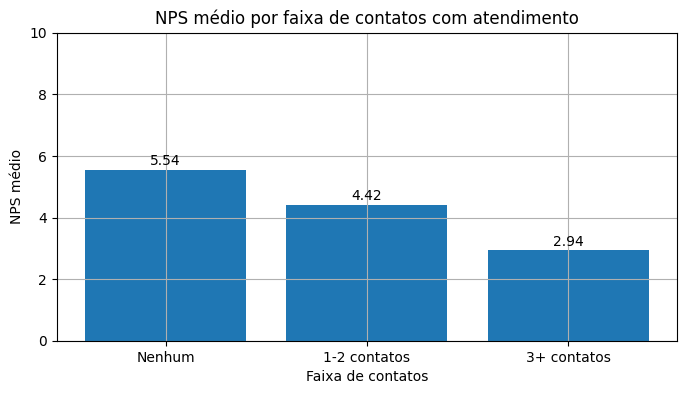

In [16]:
plt.figure(figsize=(8, 4))

plt.bar(
    resumo_p1["contact_range"].astype(str),
    resumo_p1["nps_medio"]
)

plt.title("NPS médio por faixa de contatos com atendimento")
plt.xlabel("Faixa de contatos")
plt.ylabel("NPS médio")
plt.ylim(0, 10)

for i, valor in enumerate(resumo_p1["nps_medio"]):
    plt.text(i, valor + 0.15, f"{valor:.2f}", ha="center")

plt.show()

# **Correlação da pergunta 1**

In [17]:
r, p = stats.spearmanr(
    df["customer_service_contacts"],
    df["nps_score"]
)

print("Correlação Spearman entre contatos com atendimento e NPS:", round(r, 3))
print("p-valor:", round(p, 4))

if r < 0:
    print("Leitura: quanto mais contatos com atendimento, menor tende a ser o NPS.")
else:
    print("Leitura: não apareceu relação negativa clara entre contatos e NPS.")

Correlação Spearman entre contatos com atendimento e NPS: -0.336
p-valor: 0.0
Leitura: quanto mais contatos com atendimento, menor tende a ser o NPS.


# **Pergunta 2: reclamações estão associadas à queda do NPS?**

In [18]:
resumo_p2 = (
    df.groupby("complaint_range", observed=False)
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_p2["pct_detrator"] = resumo_p2["pct_detrator"] * 100

display(resumo_p2)

,complaint_range,qtd_clientes,nps_medio,pct_detrator
0,Nenhuma,23,8.52,4.35
1,1-2,399,6.58,32.58
2,3-5,1551,4.28,78.79
3,6+,527,2.82,94.50


# **Grafico da Pergunta 2**

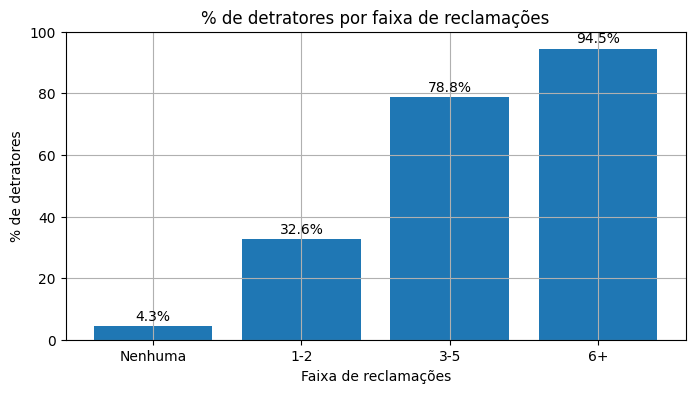

In [19]:
plt.figure(figsize=(8, 4))

plt.bar(
    resumo_p2["complaint_range"].astype(str),
    resumo_p2["pct_detrator"]
)

plt.title("% de detratores por faixa de reclamações")
plt.xlabel("Faixa de reclamações")
plt.ylabel("% de detratores")
plt.ylim(0, 100)

for i, valor in enumerate(resumo_p2["pct_detrator"]):
    plt.text(i, valor + 2, f"{valor:.1f}%", ha="center")

plt.show()

# **Correlação da pergunta 2**

In [20]:
r, p = stats.spearmanr(
    df["complaints_count"],
    df["nps_score"]
)

print("Correlação Spearman entre quantidade de reclamações e NPS:", round(r, 3))
print("p-valor:", round(p, 4))

print("\nNPS médio por quantidade exata de reclamações:")
display(
    df.groupby("complaints_count")["nps_score"]
      .mean()
      .reset_index()
)

Correlação Spearman entre quantidade de reclamações e NPS: -0.49
p-valor: 0.0

NPS médio por quantidade exata de reclamações:


,complaints_count,nps_score
0,0,8.52
1,1,7.77
2,2,6.05
3,3,4.91
4,4,4.22
5,5,3.65
6,6,3.06
7,7,2.81
8,8,2.07
9,9,2.49


# **Pergunta 3: Tempo de resolução está associado à satisfação?**

In [21]:
resumo_p3 = (
    df.groupby("resolution_range", observed=False)
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_p3["pct_detrator"] = resumo_p3["pct_detrator"] * 100

display(resumo_p3)

,resolution_range,qtd_clientes,nps_medio,pct_detrator
0,Até 2 dias,629,5.04,64.23
1,3-5 dias,619,4.51,73.18
2,6-10 dias,1038,4.04,78.42
3,11+ dias,214,3.68,84.11


# **Gráfico da pergunta 3**

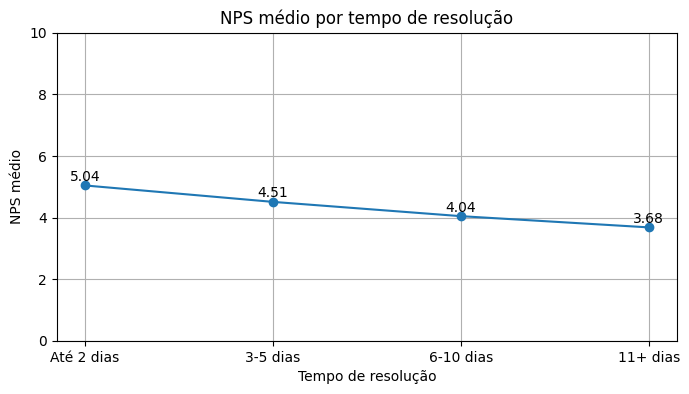

In [22]:
plt.figure(figsize=(8, 4))

plt.plot(
    resumo_p3["resolution_range"].astype(str),
    resumo_p3["nps_medio"],
    marker="o"
)

plt.title("NPS médio por tempo de resolução")
plt.xlabel("Tempo de resolução")
plt.ylabel("NPS médio")
plt.ylim(0, 10)

for i, valor in enumerate(resumo_p3["nps_medio"]):
    plt.text(i, valor + 0.15, f"{valor:.2f}", ha="center")

plt.show()

# **Correlação da pergunta 3**

In [23]:
r, p = stats.spearmanr(
    df["resolution_time_days"],
    df["nps_score"]
)

print("Correlação Spearman entre tempo de resolução e NPS:", round(r, 3))
print("p-valor:", round(p, 4))

if r < 0:
    print("Leitura: quanto maior o tempo de resolução, menor tende a ser o NPS.")
else:
    print("Leitura: não apareceu relação negativa clara.")

Correlação Spearman entre tempo de resolução e NPS: -0.19
p-valor: 0.0
Leitura: quanto maior o tempo de resolução, menor tende a ser o NPS.


# **Pergunta 4: qual fator operacional pesa mais no NPS?**

In [24]:
variaveis_operacionais = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
    "resolution_time_days",
    "delivery_attempts",
    "freight_value"
]

ranking = []

for coluna in variaveis_operacionais:
    r, p = stats.spearmanr(df[coluna], df["nps_score"])

    ranking.append({
        "variavel": coluna,
        "correlacao_spearman": r,
        "p_valor": p,
        "impacto_abs": abs(r)
    })

ranking_p4 = pd.DataFrame(ranking)

ranking_p4 = ranking_p4.sort_values(
    "impacto_abs",
    ascending=False
)

display(ranking_p4)

,variavel,correlacao_spearman,p_valor,impacto_abs
0,delivery_delay_days,-0.59,0.00,0.59
1,complaints_count,-0.49,0.00,0.49
2,customer_service_contacts,-0.34,0.00,0.34
3,resolution_time_days,-0.19,0.00,0.19
5,freight_value,-0.04,0.05,0.04
4,delivery_attempts,0.03,0.19,0.03


# **Gráfico do ranking**

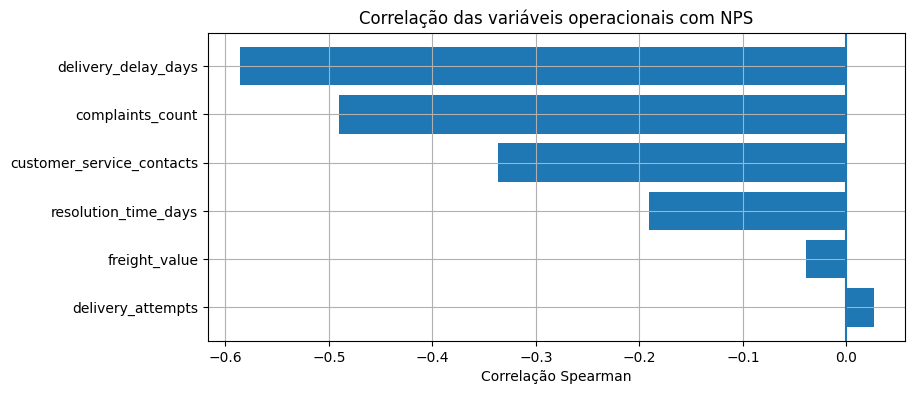

In [25]:
plt.figure(figsize=(9, 4))

plt.barh(
    ranking_p4["variavel"],
    ranking_p4["correlacao_spearman"]
)

plt.title("Correlação das variáveis operacionais com NPS")
plt.xlabel("Correlação Spearman")
plt.axvline(0)
plt.gca().invert_yaxis()

plt.show()

# **Pergunta 5: o CSAT interno acompanha o NPS?**

In [26]:
print("CSAT médio geral:")
print(round(df["csat_internal_score"].mean(), 2))

print("\nCSAT médio dos detratores:")
print(round(df.loc[df["is_detractor"] == 1, "csat_internal_score"].mean(), 2))

print("\nCSAT médio dos não detratores:")
print(round(df.loc[df["is_detractor"] == 0, "csat_internal_score"].mean(), 2))

r, p = stats.spearmanr(
    df["csat_internal_score"],
    df["nps_score"]
)

print("\nCorrelação Spearman entre CSAT interno e NPS:", round(r, 3))
print("p-valor:", round(p, 4))

CSAT médio geral:
2.94

CSAT médio dos detratores:
2.34

CSAT médio dos não detratores:
4.66

Correlação Spearman entre CSAT interno e NPS: 0.561
p-valor: 0.0


# **Gráfico CSAT x NPS**

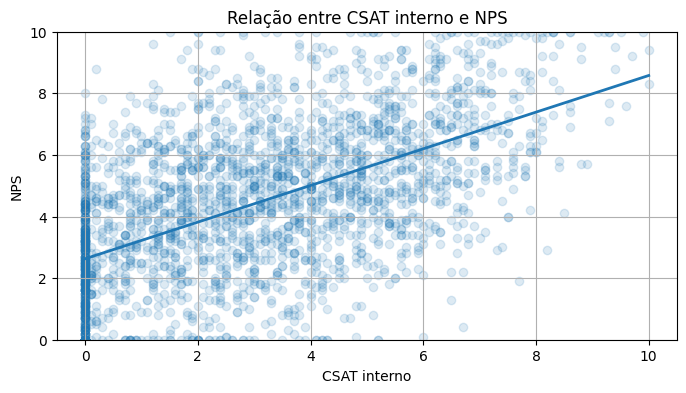

In [27]:
plt.figure(figsize=(8, 4))

plt.scatter(
    df["csat_internal_score"],
    df["nps_score"],
    alpha=0.15
)

# Linha de tendência simples
coef = np.polyfit(df["csat_internal_score"], df["nps_score"], 1)
linha = np.poly1d(coef)

x = np.linspace(
    df["csat_internal_score"].min(),
    df["csat_internal_score"].max(),
    100
)

plt.plot(x, linha(x), linewidth=2)

plt.title("Relação entre CSAT interno e NPS")
plt.xlabel("CSAT interno")
plt.ylabel("NPS")
plt.ylim(0, 10)

plt.show()

# **Pergunta 6: recompra em 30 dias tem relação com NPS?**

In [28]:
resumo_p6 = (
    df.groupby("repeat_purchase_30d")
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_p6["label"] = resumo_p6["repeat_purchase_30d"].map({
    0: "Não recomprou",
    1: "Recomprou"
})

resumo_p6["pct_detrator"] = resumo_p6["pct_detrator"] * 100

display(
    resumo_p6[["label", "qtd_clientes", "nps_medio", "pct_detrator"]]
)

,label,qtd_clientes,nps_medio,pct_detrator
0,Não recomprou,2282,3.94,81.11
1,Recomprou,218,9.01,0.00


# **Gráfico da pergunta 6**

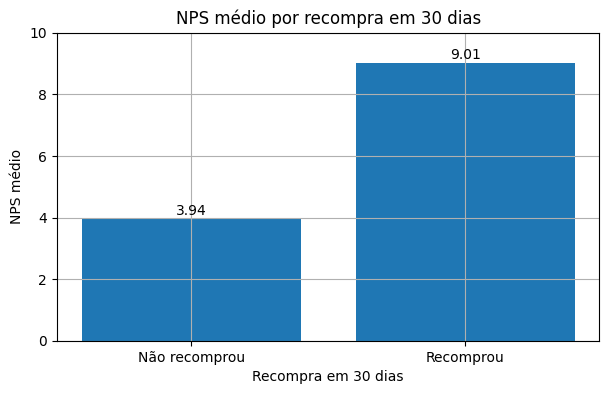

In [29]:
plt.figure(figsize=(7, 4))

plt.bar(
    resumo_p6["label"],
    resumo_p6["nps_medio"]
)

plt.title("NPS médio por recompra em 30 dias")
plt.xlabel("Recompra em 30 dias")
plt.ylabel("NPS médio")
plt.ylim(0, 10)

for i, valor in enumerate(resumo_p6["nps_medio"]):
    plt.text(i, valor + 0.15, f"{valor:.2f}", ha="center")

plt.show()

# **Pergunta 7: a insatisfação varia por região?**

In [30]:
resumo_p7 = (
    df.groupby("customer_region")
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
      .sort_values("nps_medio")
)

resumo_p7["pct_detrator"] = resumo_p7["pct_detrator"] * 100

display(resumo_p7)

,customer_region,qtd_clientes,nps_medio,pct_detrator
0,Centro-Oeste,468,4.21,74.36
3,Sudeste,520,4.37,74.62
2,Norte,506,4.38,74.51
1,Nordeste,485,4.42,74.02
4,Sul,521,4.49,72.74


# **Teste estatístico por região**

In [31]:
grupos_regiao = []

for regiao, grupo in df.groupby("customer_region"):
    grupos_regiao.append(grupo["nps_score"])

estatistica, p_valor = stats.kruskal(*grupos_regiao)

print("Teste Kruskal-Wallis para diferença de NPS entre regiões")
print("Estatística:", round(estatistica, 3))
print("p-valor:", round(p_valor, 4))

if p_valor < 0.05:
    print("Leitura: existe diferença estatística entre pelo menos duas regiões.")
else:
    print("Leitura: não apareceu diferença estatística relevante entre regiões.")

Teste Kruskal-Wallis para diferença de NPS entre regiões
Estatística: 3.379
p-valor: 0.4966
Leitura: não apareceu diferença estatística relevante entre regiões.


# **Correlação**

In [32]:
menor_nps_regiao = resumo_p7["nps_medio"].min()
maior_nps_regiao = resumo_p7["nps_medio"].max()
diferenca_regiao = maior_nps_regiao - menor_nps_regiao

print("Menor NPS médio regional:", round(menor_nps_regiao, 2))
print("Maior NPS médio regional:", round(maior_nps_regiao, 2))
print("Diferença entre regiões:", round(diferenca_regiao, 2))

if diferenca_regiao < 0.5:
    print("Leitura: a variação regional é baixa. A insatisfação parece mais operacional do que geográfica.")
else:
    print("Leitura: há diferença regional relevante que merece investigação.")

Menor NPS médio regional: 4.21
Maior NPS médio regional: 4.49
Diferença entre regiões: 0.28
Leitura: a variação regional é baixa. A insatisfação parece mais operacional do que geográfica.


# **Gráfico por região**

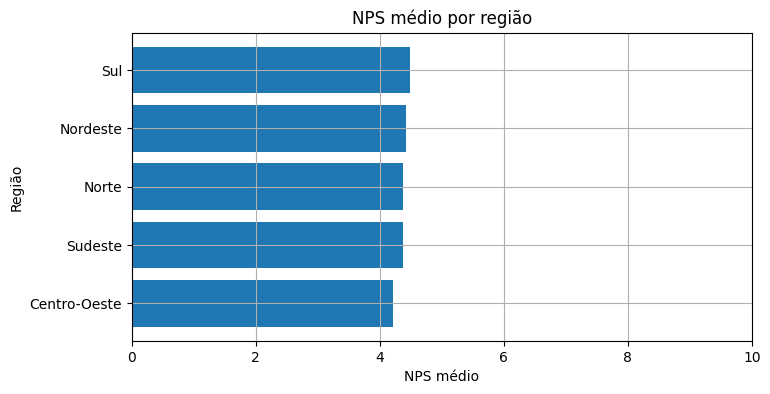

In [33]:
plt.figure(figsize=(8, 4))

plt.barh(
    resumo_p7["customer_region"],
    resumo_p7["nps_medio"]
)

plt.title("NPS médio por região")
plt.xlabel("NPS médio")
plt.ylabel("Região")
plt.xlim(0, 10)

plt.show()

# **Pergunta 8: idade e tempo de relacionamento mudam o NPS?**

In [34]:
resumo_idade = (
    df.groupby("age_range", observed=False)
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_tenure = (
    df.groupby("tenure_range", observed=False)
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_idade["pct_detrator"] = resumo_idade["pct_detrator"] * 100
resumo_tenure["pct_detrator"] = resumo_tenure["pct_detrator"] * 100

print("Idade x NPS")
display(resumo_idade)

print("Tempo de relacionamento x NPS")
display(resumo_tenure)

Idade x NPS


,age_range,qtd_clientes,nps_medio,pct_detrator
0,18-25,389,4.48,75.84
1,26-35,465,4.56,70.97
2,36-50,747,4.19,75.90
3,51+,899,4.40,73.30


Tempo de relacionamento x NPS


,tenure_range,qtd_clientes,nps_medio,pct_detrator
0,< 1 ano,242,4.15,76.03
1,1-3 anos,490,4.55,72.45
2,3-6 anos,727,4.44,72.21
3,6+ anos,1041,4.31,75.60


# **Correlação da pergunta 8**

In [35]:
r_idade, p_idade = stats.spearmanr(
    df["customer_age"],
    df["nps_score"]
)

r_tenure, p_tenure = stats.spearmanr(
    df["customer_tenure_months"],
    df["nps_score"]
)

print("Correlação idade x NPS:", round(r_idade, 3))
print("p-valor idade:", round(p_idade, 4))

print("\nCorrelação tempo de relacionamento x NPS:", round(r_tenure, 3))
print("p-valor tempo de relacionamento:", round(p_tenure, 4))

Correlação idade x NPS: -0.007
p-valor idade: 0.71

Correlação tempo de relacionamento x NPS: -0.012
p-valor tempo de relacionamento: 0.5604


# **Gráficos da pergunta 8**

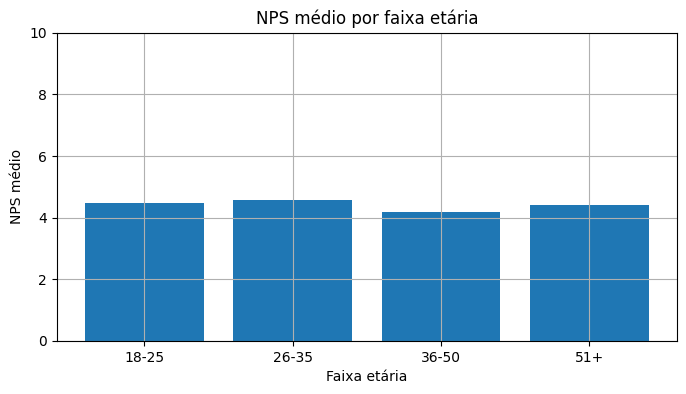

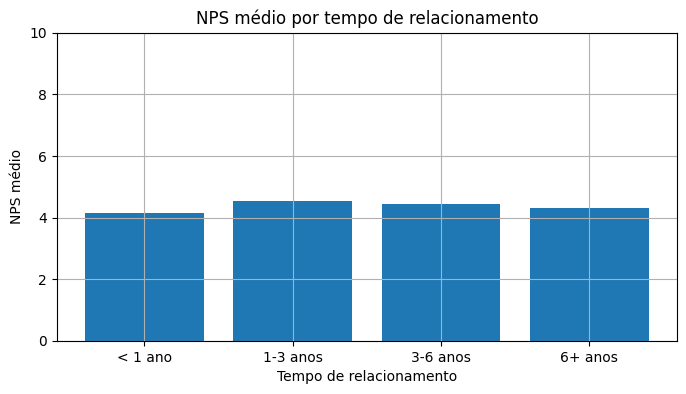

In [36]:
plt.figure(figsize=(8, 4))

plt.bar(
    resumo_idade["age_range"].astype(str),
    resumo_idade["nps_medio"]
)

plt.title("NPS médio por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("NPS médio")
plt.ylim(0, 10)

plt.show()


plt.figure(figsize=(8, 4))

plt.bar(
    resumo_tenure["tenure_range"].astype(str),
    resumo_tenure["nps_medio"]
)

plt.title("NPS médio por tempo de relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("NPS médio")
plt.ylim(0, 10)

plt.show()

# **Pergunta 9: entre clientes com atraso, o que separa detratores dos demais?**

In [37]:
df_atraso = df[df["delivery_delay_days"] > 0].copy()

print("Clientes com atraso:", len(df_atraso))

pct_base_atraso = len(df_atraso) / len(df) * 100
print("% da base com atraso:", round(pct_base_atraso, 1))

pct_detratores_atraso = df_atraso["is_detractor"].mean() * 100
print("% de detratores entre atrasados:", round(pct_detratores_atraso, 1))

Clientes com atraso: 2223
% da base com atraso: 88.9
% de detratores entre atrasados: 78.7


# **Comparar detratores e não detratores**

In [38]:
comparacao_simples = (
    df.groupby("is_detractor")
      .agg(
          media_contatos=("customer_service_contacts", "mean"),
          media_reclamacoes=("complaints_count", "mean"),
          tempo_resolucao_medio=("resolution_time_days", "mean"),
          csat_medio=("csat_internal_score", "mean"),
          recompra_30d=("repeat_purchase_30d", "mean")
      )
      .reset_index()
)

comparacao_simples["grupo"] = comparacao_simples["is_detractor"].map({
    0: "Não detrator",
    1: "Detrator"
})

comparacao_simples["recompra_30d"] = comparacao_simples["recompra_30d"] * 100

display(comparacao_simples)

,is_detractor,media_contatos,media_reclamacoes,tempo_resolucao_medio,csat_medio,recompra_30d,grupo
0,0,1.02,2.80,4.61,4.66,33.59,Não detrator
1,1,1.69,4.62,5.79,2.34,0.00,Detrator


# **Gráfico da pergunta 9**

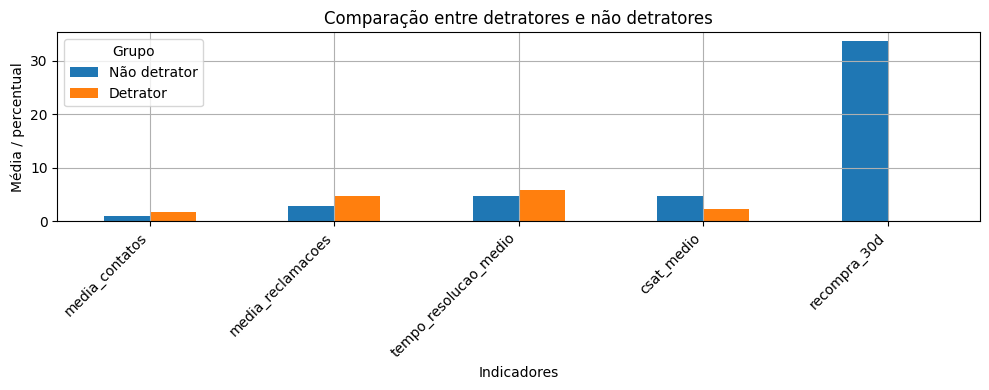

In [39]:
comparacao_plot = comparacao_simples.set_index("grupo")[[
    "media_contatos",
    "media_reclamacoes",
    "tempo_resolucao_medio",
    "csat_medio",
    "recompra_30d"
]].T

comparacao_plot.plot(kind="bar", figsize=(10, 4))

plt.title("Comparação entre detratores e não detratores")
plt.xlabel("Indicadores")
plt.ylabel("Média / percentual")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()

# **Pergunta 10: dá para criar um score simples de risco de detrator?**

In [40]:
df["risco_atraso"] = (df["delivery_delay_days"] >= 3).astype(int)
df["risco_reclamacao"] = (df["complaints_count"] >= 3).astype(int)
df["risco_contato"] = (df["customer_service_contacts"] >= 2).astype(int)

df["score_risco"] = (
    df["risco_atraso"] +
    df["risco_reclamacao"] +
    df["risco_contato"]
)

resumo_p10 = (
    df.groupby("score_risco")
      .agg(
          qtd_clientes=("customer_id", "count"),
          nps_medio=("nps_score", "mean"),
          pct_detrator=("is_detractor", "mean")
      )
      .reset_index()
)

resumo_p10["pct_detrator"] = resumo_p10["pct_detrator"] * 100

display(resumo_p10)

,score_risco,qtd_clientes,nps_medio,pct_detrator
0,0,320,7.22,23.12
1,1,603,5.33,64.84
2,2,1164,3.96,84.54
3,3,413,1.98,97.34


# **Gráfico do score de risco**

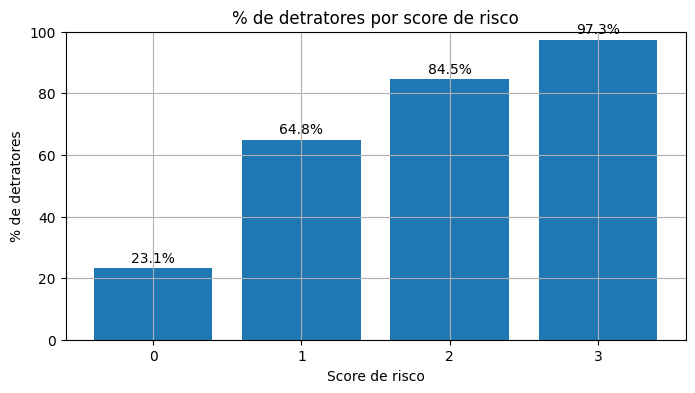

In [41]:
plt.figure(figsize=(8, 4))

plt.bar(
    resumo_p10["score_risco"].astype(str),
    resumo_p10["pct_detrator"]
)

plt.title("% de detratores por score de risco")
plt.xlabel("Score de risco")
plt.ylabel("% de detratores")
plt.ylim(0, 100)

for i, valor in enumerate(resumo_p10["pct_detrator"]):
    plt.text(i, valor + 2, f"{valor:.1f}%", ha="center")

plt.show()

# **Explicar regra do score**

In [42]:
print("Regras usadas no score:")
print("+1 se atraso na entrega for maior ou igual a 3 dias")
print("+1 se o cliente tiver 3 ou mais reclamações")
print("+1 se o cliente tiver 2 ou mais contatos com atendimento")

print("\nClassificação sugerida:")
print("Score 0: baixo risco")
print("Score 1: acompanhar")
print("Score 2: priorizar atendimento")
print("Score 3: ação urgente para evitar detrator")

Regras usadas no score:
+1 se atraso na entrega for maior ou igual a 3 dias
+1 se o cliente tiver 3 ou mais reclamações
+1 se o cliente tiver 2 ou mais contatos com atendimento

Classificação sugerida:
Score 0: baixo risco
Score 1: acompanhar
Score 2: priorizar atendimento
Score 3: ação urgente para evitar detrator


# **Resumo final da análise**

In [43]:
print("Resumo final da EDA")
print("-" * 40)

print("Total de clientes analisados:", len(df))
print("NPS médio geral:", round(df["nps_score"].mean(), 2))
print("% de detratores:", round(df["is_detractor"].mean() * 100, 2), "%")
print("Média de contatos com atendimento:", round(df["customer_service_contacts"].mean(), 2))
print("Média de reclamações:", round(df["complaints_count"].mean(), 2))
print("Tempo médio de resolução:", round(df["resolution_time_days"].mean(), 2))
print("Atraso médio:", round(df["delivery_delay_days"].mean(), 2))
print("CSAT médio:", round(df["csat_internal_score"].mean(), 2))
print("% recompra em 30 dias:", round(df["repeat_purchase_30d"].mean() * 100, 2), "%")

Resumo final da EDA
----------------------------------------
Total de clientes analisados: 2500
NPS médio geral: 4.38
% de detratores: 74.04 %
Média de contatos com atendimento: 1.52
Média de reclamações: 4.15
Tempo médio de resolução: 5.49
Atraso médio: 2.19
CSAT médio: 2.94
% recompra em 30 dias: 8.72 %


# **insights_finais**

In [50]:
from IPython.display import display, Markdown

explicacao_metricas = """
## Como interpretar os principais indicadores

Antes de apresentar os resultados da EDA, é importante explicar os principais indicadores usados na análise.

### NPS médio

É a média das notas de NPS dadas pelos clientes, em uma escala de 0 a 10.
Quanto maior o valor, maior tende a ser a satisfação média da base analisada.

---

### Categoria de NPS

A nota de NPS foi classificada em três grupos, seguindo o critério operacional definido para o projeto:

- **Detrator:** clientes com nota de 0 a 6;
- **Neutro:** clientes com nota maior que 6 e menor que 9;
- **Promotor:** clientes com nota igual ou maior que 9.

Essa classificação ajuda a transformar a nota numérica em uma leitura de comportamento do cliente.

---

### Percentual de detratores

Mostra qual percentual de clientes de determinado grupo foi classificado como detrator.

Exemplo: se uma faixa de clientes tem 90% de detratores, significa que 9 em cada 10 clientes daquele grupo deram uma nota baixa de NPS.

---

### Correlação de Spearman

A correlação de Spearman mede se duas variáveis caminham juntas de forma crescente ou decrescente.

A leitura geral é:

- Valor próximo de **+1**: quando uma variável aumenta, a outra também tende a aumentar;
- Valor próximo de **-1**: quando uma variável aumenta, a outra tende a diminuir;
- Valor próximo de **0**: não há uma relação clara entre as variáveis.

Exemplo: se `complaints_count` tem correlação negativa com `nps_score`, significa que clientes com mais reclamações tendem a ter NPS menor.

---

### P-valor

O p-valor indica se a relação encontrada tem evidência estatística ou se pode ter ocorrido por acaso.

A leitura prática usada na análise foi:

- **p-valor menor que 0,05:** a relação é estatisticamente significativa;
- **p-valor maior que 0,05:** não há evidência suficiente para afirmar que existe relação.

Quando o Python mostra `0.0`, isso não significa que o valor seja exatamente zero, mas que ele é muito pequeno.

---

### CSAT interno

O CSAT interno é uma nota de satisfação relacionada ao atendimento ou experiência interna do cliente.
Na análise, ele foi comparado com o NPS para verificar se poderia funcionar como um indicador antecipado de satisfação.

---

### Recompra em 30 dias

Indica se o cliente realizou uma nova compra em até 30 dias.
Essa variável ajuda a entender comportamento de fidelização, mas deve ser interpretada com cuidado, porque pode ser consequência da satisfação, e não necessariamente causa dela.
"""

display(Markdown(explicacao_metricas))


## Como interpretar os principais indicadores

Antes de apresentar os resultados da EDA, é importante explicar os principais indicadores usados na análise.

### NPS médio

É a média das notas de NPS dadas pelos clientes, em uma escala de 0 a 10.
Quanto maior o valor, maior tende a ser a satisfação média da base analisada.

---

### Categoria de NPS

A nota de NPS foi classificada em três grupos, seguindo o critério operacional definido para o projeto:

- **Detrator:** clientes com nota de 0 a 6;
- **Neutro:** clientes com nota maior que 6 e menor que 9;
- **Promotor:** clientes com nota igual ou maior que 9.

Essa classificação ajuda a transformar a nota numérica em uma leitura de comportamento do cliente.

---

### Percentual de detratores

Mostra qual percentual de clientes de determinado grupo foi classificado como detrator.

Exemplo: se uma faixa de clientes tem 90% de detratores, significa que 9 em cada 10 clientes daquele grupo deram uma nota baixa de NPS.

---

### Correlação de Spearman

A correlação de Spearman mede se duas variáveis caminham juntas de forma crescente ou decrescente.

A leitura geral é:

- Valor próximo de **+1**: quando uma variável aumenta, a outra também tende a aumentar;
- Valor próximo de **-1**: quando uma variável aumenta, a outra tende a diminuir;
- Valor próximo de **0**: não há uma relação clara entre as variáveis.

Exemplo: se `complaints_count` tem correlação negativa com `nps_score`, significa que clientes com mais reclamações tendem a ter NPS menor.

---

### P-valor

O p-valor indica se a relação encontrada tem evidência estatística ou se pode ter ocorrido por acaso.

A leitura prática usada na análise foi:

- **p-valor menor que 0,05:** a relação é estatisticamente significativa;
- **p-valor maior que 0,05:** não há evidência suficiente para afirmar que existe relação.

Quando o Python mostra `0.0`, isso não significa que o valor seja exatamente zero, mas que ele é muito pequeno.

---

### CSAT interno

O CSAT interno é uma nota de satisfação relacionada ao atendimento ou experiência interna do cliente.
Na análise, ele foi comparado com o NPS para verificar se poderia funcionar como um indicador antecipado de satisfação.

---

### Recompra em 30 dias

Indica se o cliente realizou uma nova compra em até 30 dias.
Essa variável ajuda a entender comportamento de fidelização, mas deve ser interpretada com cuidado, porque pode ser consequência da satisfação, e não necessariamente causa dela.


In [45]:
from IPython.display import display, Markdown

decisoes_operacionais = """
## Decisões operacionais sugeridas

### 1. Criar fila de recuperação para clientes com 3+ reclamações
Clientes com 3 a 5 reclamações já apresentam 78,79% de detratores.
Clientes com 6 ou mais reclamações chegam a 94,50% de detratores.

**Ação:** acionar célula de recuperação antes de nova reclamação.

---

### 2. Criar alerta para clientes com 3+ contatos no atendimento
Clientes com 3 ou mais contatos apresentam NPS médio de 2,94 e 90,41% de detratores.

**Ação:** priorizar atendimento humano ou revisão do caso na terceira interação.

---

### 3. Tratar resolução longa como agravante
Clientes com resolução acima de 11 dias apresentam 84,11% de detratores.

**Ação:** monitorar clientes com resolução acima de 6 dias e escalar casos críticos.

---

### 4. Não priorizar estratégia por região
A variação regional do NPS é baixa e o teste estatístico não indicou diferença relevante.

**Ação:** priorizar problemas da jornada, e não campanhas regionais.

---

### 5. Usar score de risco como régua operacional
Clientes com score 2 já têm 84,54% de detratores.
Clientes com score 3 chegam a 97,34%.

**Ação:** score 2 = priorização; score 3 = atuação urgente.
"""

display(Markdown(decisoes_operacionais))


## Decisões operacionais sugeridas

### 1. Criar fila de recuperação para clientes com 3+ reclamações
Clientes com 3 a 5 reclamações já apresentam 78,79% de detratores.
Clientes com 6 ou mais reclamações chegam a 94,50% de detratores.

**Ação:** acionar célula de recuperação antes de nova reclamação.

---

### 2. Criar alerta para clientes com 3+ contatos no atendimento
Clientes com 3 ou mais contatos apresentam NPS médio de 2,94 e 90,41% de detratores.

**Ação:** priorizar atendimento humano ou revisão do caso na terceira interação.

---

### 3. Tratar resolução longa como agravante
Clientes com resolução acima de 11 dias apresentam 84,11% de detratores.

**Ação:** monitorar clientes com resolução acima de 6 dias e escalar casos críticos.

---

### 4. Não priorizar estratégia por região
A variação regional do NPS é baixa e o teste estatístico não indicou diferença relevante.

**Ação:** priorizar problemas da jornada, e não campanhas regionais.

---

### 5. Usar score de risco como régua operacional
Clientes com score 2 já têm 84,54% de detratores.
Clientes com score 3 chegam a 97,34%.

**Ação:** score 2 = priorização; score 3 = atuação urgente.
